<center><h1>Shelar_Kartik_HW2</h1></center>
<br>
<br>

Name: Kartik Shelar
<br>
Github Username: kartikshelar
<br>
USC ID: 4217403571

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor





Get the Cycle Power Plant Data Set

In [2]:
file_path = "../data/CCPP/Folds5x2_pp.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    engine="openpyxl"
)

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
num_rows, num_columns = df.shape

print("Number of rows:", num_rows)
print("Number of columns:", num_columns)
print("Column names:", df.columns.tolist())

Number of rows: 9568
Number of columns: 5
Column names: ['AT', 'V', 'AP', 'RH', 'PE']


The dataset contains 9,568 rows and 5 columns.

#### ii. pairwise scatterplots of all the varianbles

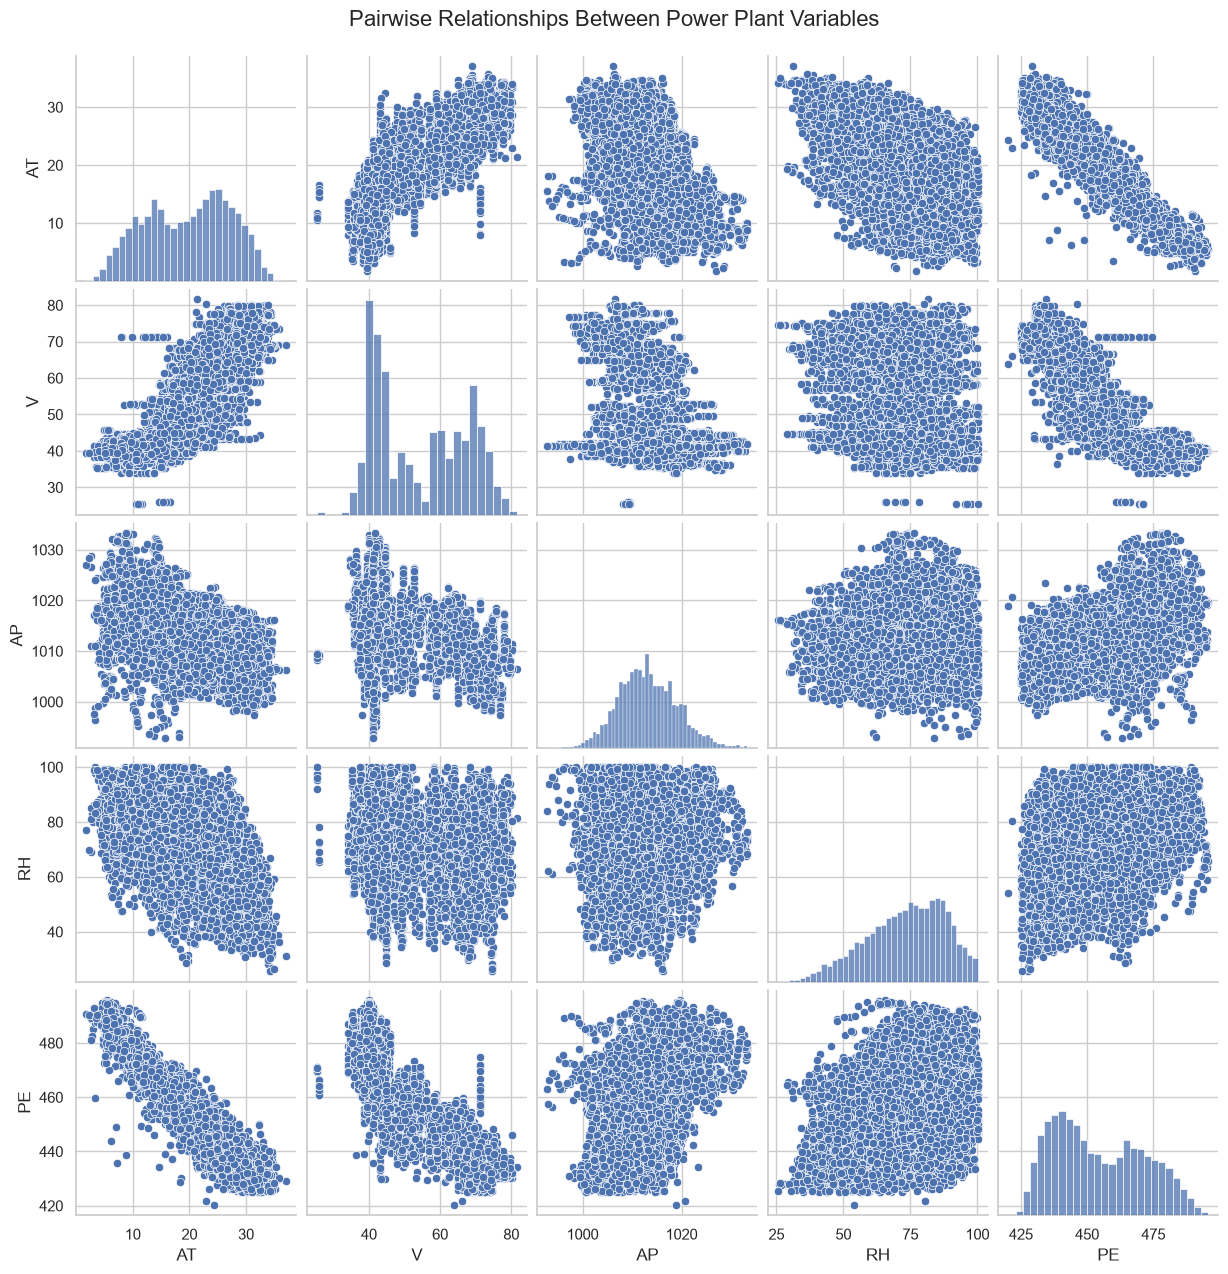

In [4]:
sns.set_theme(style="whitegrid")

pair_plot = sns.pairplot(
    df,
    diag_kind="hist",
    
)

pair_plot.figure.suptitle(
    "Pairwise Relationships Between Power Plant Variables",
    y=1.02,
    fontsize=16
)

plt.show()

In [5]:
correlation_matrix = df.corr()

correlation_matrix.round(3)

,AT,V,AP,RH,PE
AT,1.000,0.844,-0.508,-0.543,-0.948
V,0.844,1.000,-0.414,-0.312,-0.870
AP,-0.508,-0.414,1.000,0.100,0.518
RH,-0.543,-0.312,0.100,1.000,0.390
PE,-0.948,-0.870,0.518,0.390,1.000


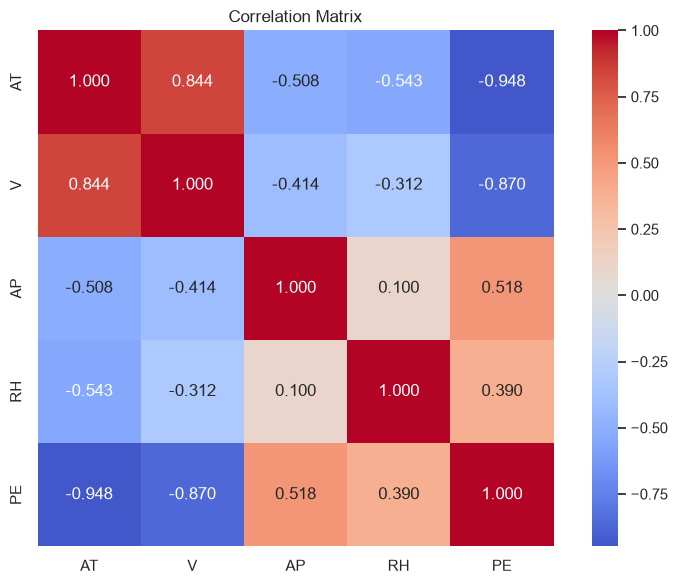

In [6]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

The pairwise scatterplots show that electrical energy output (PE) has a strong negative relationship with ambient temperature (AT) and exhaust vacuum (V). The correlations are approximately −0.948 and −0.870, respectively. This indicates that power output generally decreases as temperature or exhaust vacuum increases.

Ambient pressure (AP) has a moderate positive relationship with power output, with a correlation of approximately 0.518. Relative humidity (RH) has a weaker positive relationship with power output, with a correlation of approximately 0.390. Among the predictors, AT and V are strongly positively related, with a correlation of approximately 0.844. This suggests possible multicollinearity if both variables are included in a regression model.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [7]:
summary_table = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Range": df.max() - df.min(),
    "First Quartile (Q1)": df.quantile(0.25),
    "Third Quartile (Q3)": df.quantile(0.75),
    "IQR": df.quantile(0.75) - df.quantile(0.25)
})

summary_table.round(3)

,Mean,Median,Minimum,Maximum,Range,First Quartile (Q1),Third Quartile (Q3),IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


Ambient pressure (AP) has the smallest interquartile range relative to its numerical scale, indicating that its middle 50% of observations are concentrated within a relatively narrow interval. Relative humidity (RH) has the largest overall range, while electrical energy output (PE) ranges from 420.26 to 495.76. The mean and median of each variable are reasonably close, although V, RH, and PE show some differences that suggest mild asymmetry in their distributions.

### (c) Simple Linear Regression

In [8]:
predictors = ["AT", "V", "AP", "RH"]
models = {}
results = []

for predictor in predictors:
    X = sm.add_constant(df[[predictor]])
    y = df["PE"]

    model = sm.OLS(y, X).fit()
    models[predictor] = model

    results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Slope": model.params[predictor],
        "Slope SE": model.bse[predictor],
        "t-statistic": model.tvalues[predictor],
        "p-value": model.pvalues[predictor],
        "R-squared": model.rsquared,
        "RMSE": np.sqrt(model.mse_resid)
    })

regression_results = pd.DataFrame(results)
regression_results.round(4)

,Predictor,Intercept,Slope,Slope SE,t-statistic,p-value,R-squared,RMSE
0,AT,497.0341,-2.1713,0.0074,-291.7152,0.0,0.8989,5.4257
1,V,517.8015,-1.1681,0.0068,-172.4015,0.0,0.7565,8.4220
2,AP,-1055.2610,1.4899,0.0251,59.2962,0.0,0.2688,14.5951
3,RH,420.9618,0.4557,0.0110,41.3987,0.0,0.1519,15.7179


In [9]:
for predictor, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"Simple linear regression: PE versus {predictor}")
    print("=" * 60)
    print(model.summary())


Simple linear regression: PE versus AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:13:00   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

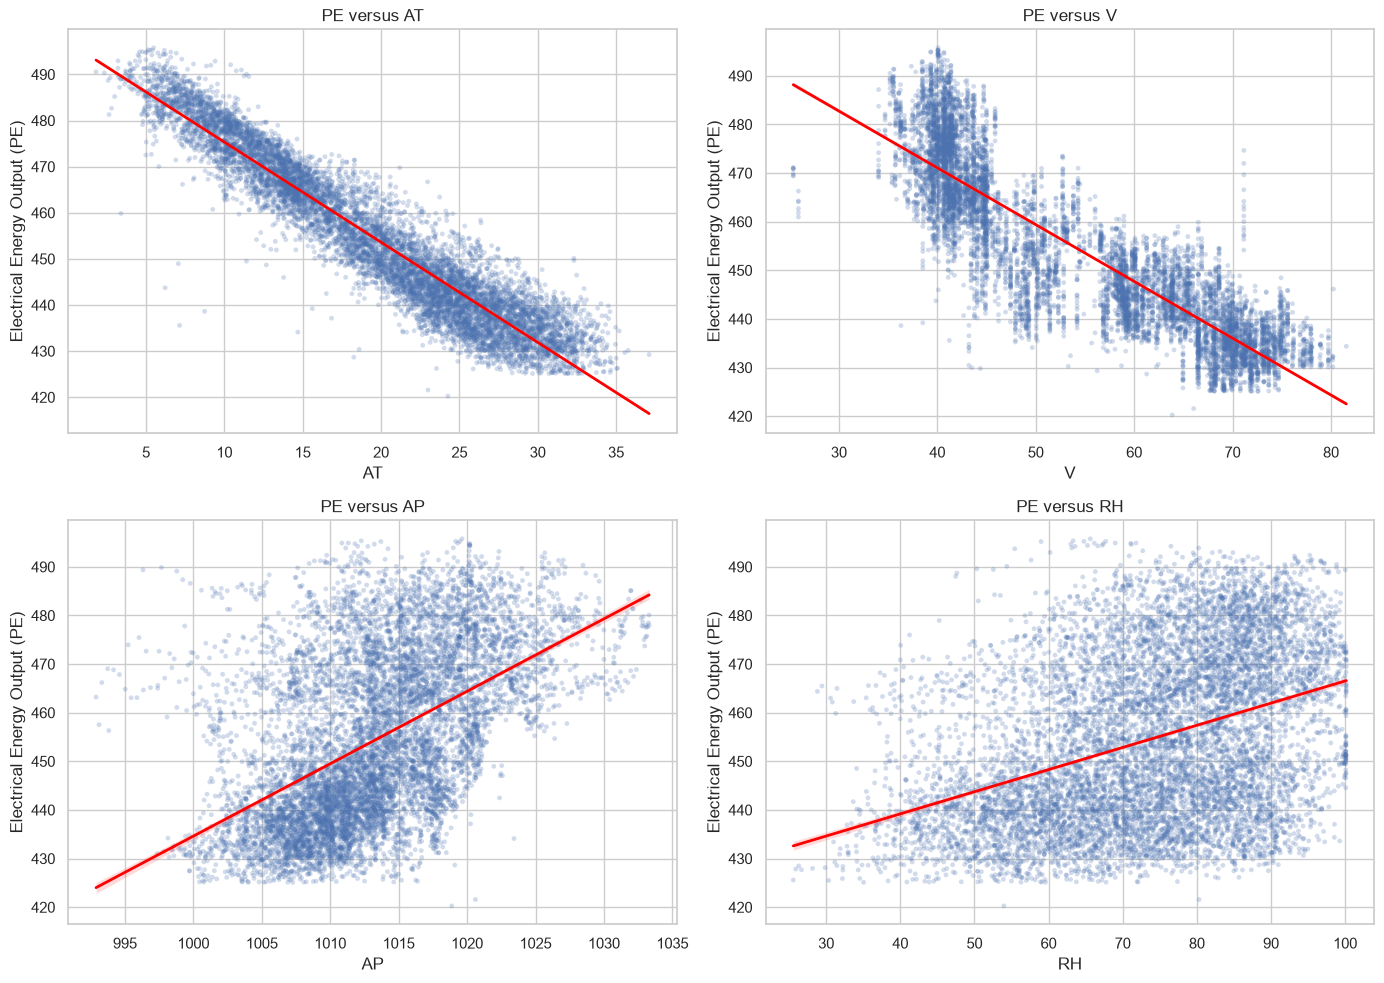

In [10]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    sns.regplot(
        data=df,
        x=predictor,
        y="PE",
        ax=ax,
        scatter_kws={
            "alpha": 0.25,
            "s": 12,
            "edgecolor": "none"
        },
        line_kws={
            "color": "red",
            "linewidth": 2
        }
    )

    ax.set_title(f"PE versus {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("Electrical Energy Output (PE)")

plt.tight_layout()
plt.show()

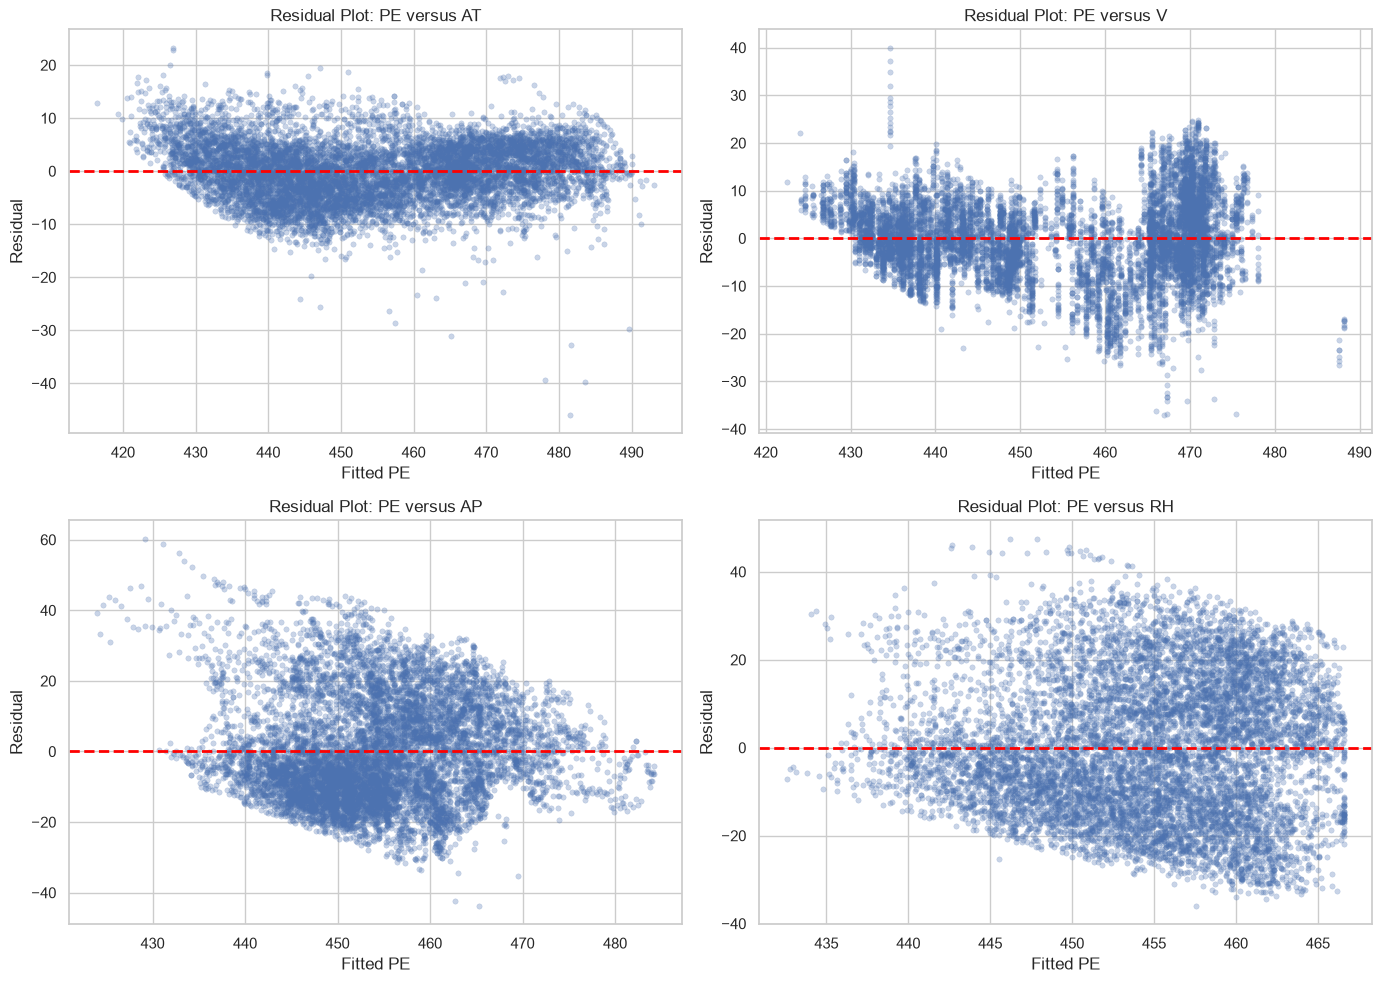

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    model = models[predictor]

    sns.scatterplot(
        x=model.fittedvalues,
        y=model.resid,
        ax=ax,
        alpha=0.3,
        s=15,
        edgecolor=None
    )

    ax.axhline(0, color="red", linestyle="--", linewidth=2)
    ax.set_title(f"Residual Plot: PE versus {predictor}")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.show()

All four predictors have a statistically significant association with electrical energy output because their slope p-values are less than 0.001. However, statistical significance does not mean that all four models have equally strong predictive performance. The very small p-values are also partly influenced by the large sample size of 9,568 observations.

Ambient temperature (AT) has the strongest individual association with PE. Its slope is approximately −2.171, meaning that a one-unit increase in ambient temperature is associated with an average decrease of approximately 2.171 units in electrical energy output. Its \(R^2\) is approximately 0.899, so temperature alone explains about 89.9% of the variation in power output.

Exhaust vacuum (V) also has a strong negative association with power output. A one-unit increase in V is associated with an average decrease of approximately 1.168 units in PE. This model explains approximately 75.7% of the variation in power output.

Ambient pressure (AP) has a statistically significant positive association with power output. A one-unit increase in pressure is associated with an average increase of approximately 1.490 units in PE. However, its \(R^2\) is only approximately 0.269.

Relative humidity (RH) also has a statistically significant positive association with power output. A one-unit increase in humidity is associated with an average increase of approximately 0.456 units in PE. Its \(R^2\) is approximately 0.152, making it the weakest of the four individual regression models.

The scatterplots and residual plots suggest that some relationships may contain curvature and changing residual variability. Therefore, although all four linear associations are statistically significant, simple linear regression may not capture every aspect of these relationships.

In [12]:
outlier_results = []
outlier_rows = {}

# Average leverage for a simple regression with n observations is (p+1)/n = 2/n
average_leverage = 2 / len(df)

for predictor, model in models.items():
    influence = model.get_influence()

    studentized_residuals = influence.resid_studentized_external
    cooks_distance = influence.cooks_distance[0]
    leverage = influence.hat_matrix_diag

    diagnostic_df = pd.DataFrame({
        "Original_Index": df.index,
        "Studentized_Residual": studentized_residuals,
        "Cooks_Distance": cooks_distance,
        "Leverage": leverage
    })

    # Potential response outliers (ISLR 3.3.3: |studentized residual| > 3)
    diagnostic_df["Potential_Outlier"] = (
        diagnostic_df["Studentized_Residual"].abs() > 3
    )

    # High-leverage points (ISLR 3.3.3: leverage well above the average (p+1)/n)
    diagnostic_df["High_Leverage"] = (
        diagnostic_df["Leverage"] > 2 * average_leverage
    )

    # Highly influential observations
    diagnostic_df["Highly_Influential"] = (
        diagnostic_df["Cooks_Distance"] > 1
    )

    outlier_rows[predictor] = diagnostic_df

    outlier_results.append({
        "Predictor": predictor,
        "|Studentized residual| > 3": (
            diagnostic_df["Potential_Outlier"].sum()
        ),
        "Leverage > 2x average": (
            diagnostic_df["High_Leverage"].sum()
        ),
        "Cook's distance > 1": (
            diagnostic_df["Highly_Influential"].sum()
        ),
        "Maximum Cook's distance": (
            diagnostic_df["Cooks_Distance"].max()
        )
    })

outlier_summary = pd.DataFrame(outlier_results)
outlier_summary.round(5)

,Predictor,|Studentized residual| > 3,Leverage > 2x average,Cook's distance > 1,Maximum Cook's distance
0,AT,42,480,0,0.01432
1,V,33,155,0,0.00324
2,AP,30,784,0,0.00815
3,RH,2,707,0,0.00206


In [13]:
for predictor in predictors:
    flagged = outlier_rows[predictor][
        outlier_rows[predictor]["Potential_Outlier"]
    ]

    print(f"{predictor}: {len(flagged)} potential outliers")
    display(flagged.head(10))

AT: 42 potential outliers


,Original_Index,Studentized_Residual,Cooks_Distance,Leverage,Potential_Outlier,High_Leverage,Highly_Influential
202,202,3.455406,0.000650,0.000109,True,False,False
437,437,-3.098465,0.000904,0.000189,True,False,False
464,464,3.428586,0.001110,0.000189,True,False,False
611,611,3.329827,0.001051,0.000190,True,False,False
786,786,3.252832,0.001404,0.000266,True,False,False
887,887,3.155273,0.001260,0.000253,True,False,False
930,930,3.683900,0.002808,0.000414,True,False,False
1438,1438,-4.415044,0.001316,0.000135,True,False,False
1568,1568,-4.198891,0.002045,0.000232,True,False,False
1615,1615,-3.054044,0.000566,0.000122,True,False,False


V: 33 potential outliers


,Original_Index,Studentized_Residual,Cooks_Distance,Leverage,Potential_Outlier,High_Leverage,Highly_Influential
182,182,3.786100,0.002061,0.000288,True,False,False
1376,1376,-3.239547,0.001007,0.000192,True,False,False
1438,1438,-3.992615,0.002116,0.000266,True,False,False
1709,1709,4.432613,0.002824,0.000288,True,False,False
1773,1773,3.146028,0.001424,0.000288,True,False,False
1985,1985,-4.383169,0.001766,0.000184,True,False,False
2217,2217,-3.055043,0.002928,0.000628,True,True,False
2335,2335,-3.112863,0.000633,0.000131,True,False,False
2385,2385,-3.092651,0.000843,0.000176,True,False,False
2492,2492,-3.861691,0.001372,0.000184,True,False,False


AP: 30 potential outliers


,Original_Index,Studentized_Residual,Cooks_Distance,Leverage,Potential_Outlier,High_Leverage,Highly_Influential
618,618,3.180763,0.002033,0.000402,True,False,False
1091,1091,3.185185,0.005412,0.001067,True,True,False
1290,1290,4.133681,0.008152,0.000955,True,True,False
1662,1662,3.588967,0.004144,0.000644,True,True,False
1735,1735,3.285757,0.002576,0.000478,True,True,False
1796,1796,3.030731,0.001331,0.000290,True,False,False
1907,1907,3.861804,0.005402,0.000725,True,True,False
1996,1996,3.163810,0.001912,0.000382,True,False,False
2047,2047,3.234948,0.002715,0.000519,True,True,False
2776,2776,3.119031,0.001366,0.000281,True,False,False


RH: 2 potential outliers


,Original_Index,Studentized_Residual,Cooks_Distance,Leverage,Potential_Outlier,High_Leverage,Highly_Influential
4719,4719,3.015318,0.000932,0.000205,True,False,False
7900,7900,3.023530,0.001193,0.000261,True,False,False


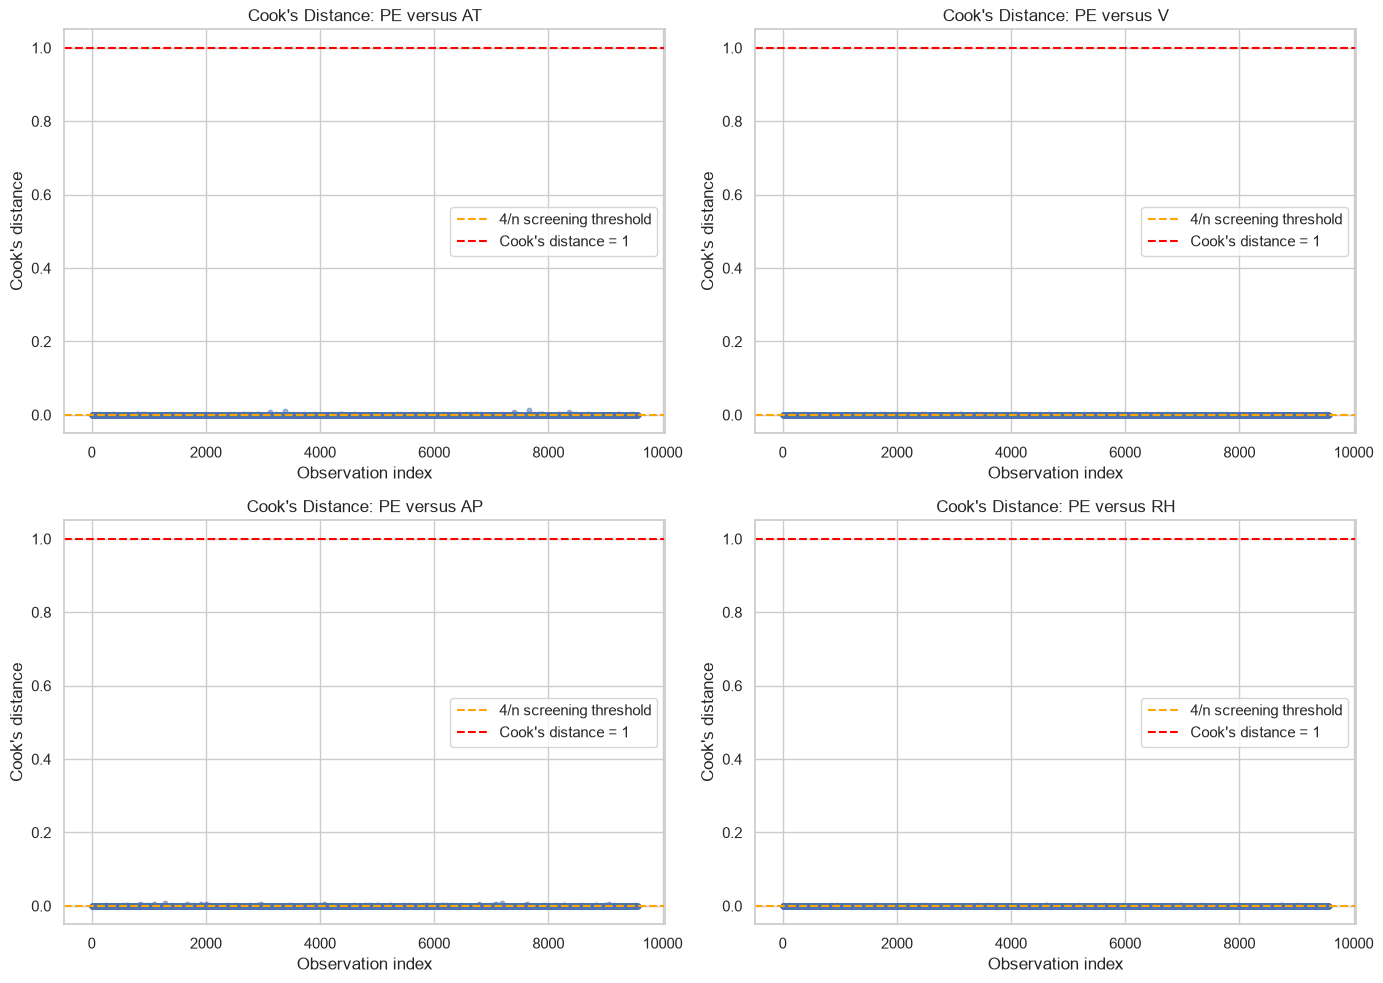

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    cooks_distance = outlier_rows[predictor]["Cooks_Distance"]

    ax.scatter(
        np.arange(len(cooks_distance)),
        cooks_distance,
        alpha=0.5,
        s=10
    )

    ax.axhline(
        4 / len(df),
        color="orange",
        linestyle="--",
        label="4/n screening threshold"
    )

    ax.axhline(
        1,
        color="red",
        linestyle="--",
        label="Cook's distance = 1"
    )

    ax.set_title(f"Cook's Distance: PE versus {predictor}")
    ax.set_xlabel("Observation index")
    ax.set_ylabel("Cook's distance")
    ax.legend()

plt.tight_layout()
plt.show()

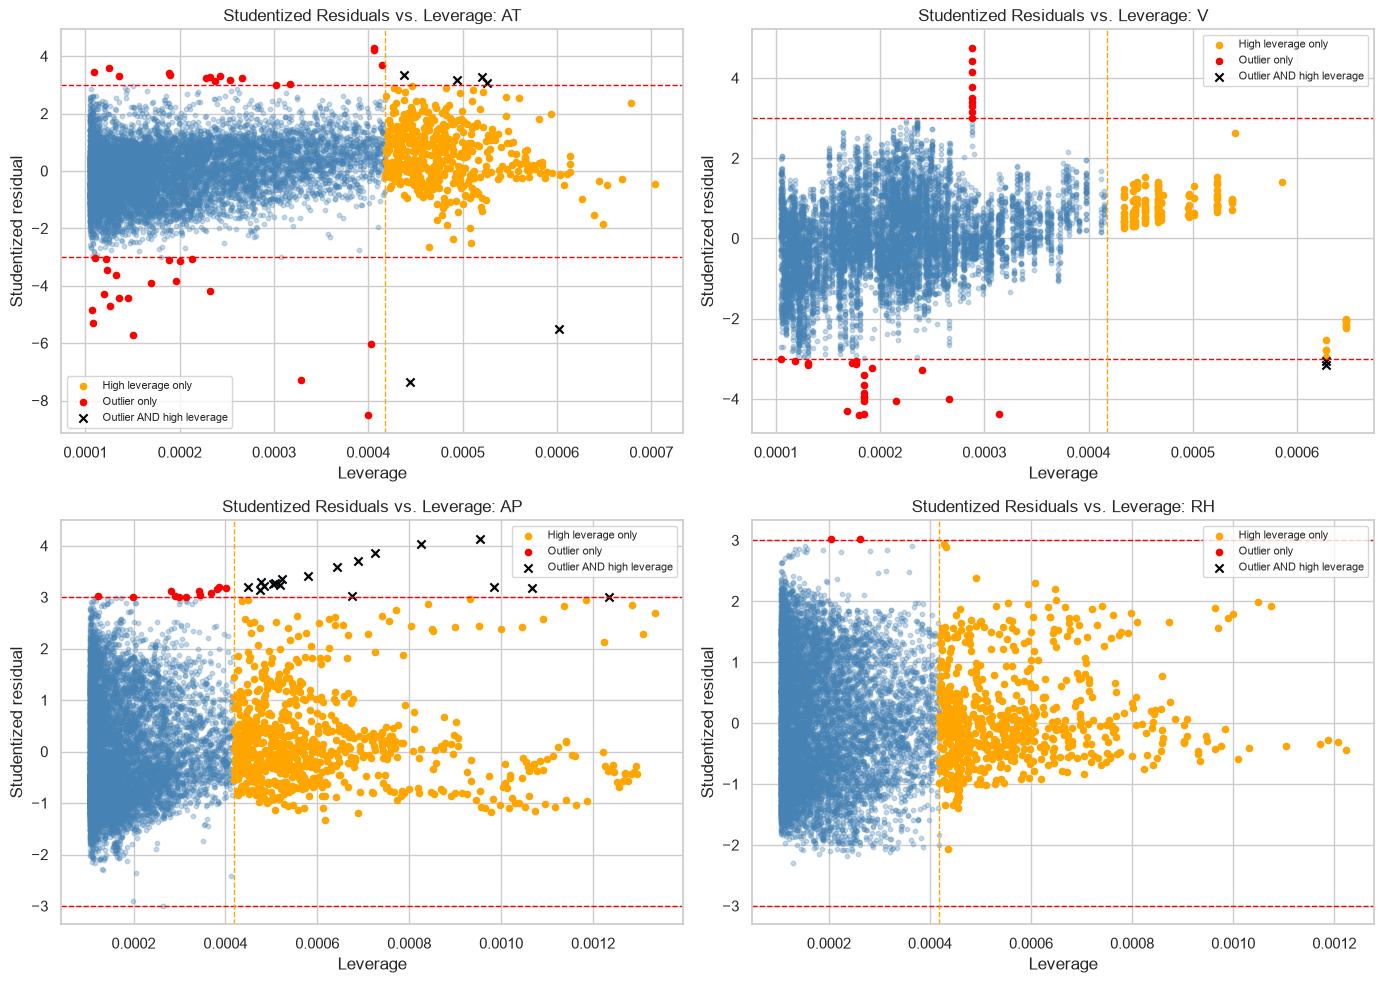

In [15]:
# Following ISLR Section 3.3.3 (Figure 3.13): plot studentized residuals against
# leverage for each predictor. A point that is both a high residual (|.| > 3)
# and high leverage is the most dangerous combination -- it is both an outlier
# and influential over the fit.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    diagnostic_df = outlier_rows[predictor]

    ax.scatter(
        diagnostic_df["Leverage"],
        diagnostic_df["Studentized_Residual"],
        alpha=0.3,
        s=10,
        color="steelblue"
    )

    # Highlight points that are outliers, high leverage, or both
    both = diagnostic_df["Potential_Outlier"] & diagnostic_df["High_Leverage"]
    outlier_only = diagnostic_df["Potential_Outlier"] & ~diagnostic_df["High_Leverage"]
    leverage_only = diagnostic_df["High_Leverage"] & ~diagnostic_df["Potential_Outlier"]

    ax.scatter(
        diagnostic_df.loc[leverage_only, "Leverage"],
        diagnostic_df.loc[leverage_only, "Studentized_Residual"],
        color="orange",
        s=20,
        label="High leverage only"
    )
    ax.scatter(
        diagnostic_df.loc[outlier_only, "Leverage"],
        diagnostic_df.loc[outlier_only, "Studentized_Residual"],
        color="red",
        s=20,
        label="Outlier only"
    )
    ax.scatter(
        diagnostic_df.loc[both, "Leverage"],
        diagnostic_df.loc[both, "Studentized_Residual"],
        color="black",
        s=35,
        marker="x",
        label="Outlier AND high leverage"
    )

    ax.axhline(3, color="red", linestyle="--", linewidth=1)
    ax.axhline(-3, color="red", linestyle="--", linewidth=1)
    ax.axvline(
        2 * average_leverage,
        color="orange",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(f"Studentized Residuals vs. Leverage: {predictor}")
    ax.set_xlabel("Leverage")
    ax.set_ylabel("Studentized residual")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Some observations have absolute studentized residuals greater than 3, particularly in the AT, V, and AP models (42, 33, and 30 observations respectively, versus only 2 for RH); per ISLR Section 3.3.3, these are potential outliers. However, the maximum Cook’s distances are approximately 0.014 for AT, 0.003 for V, 0.008 for AP, and 0.002 for RH -- all far below 1, indicating that no individual observation has an exceptionally large influence on any fitted model.

Following the same section, I also checked leverage $h_i$ for each predictor, flagging points with leverage more than twice the average leverage $(p+1)/n$. Several hundred points exceed this threshold in each model, which is expected in a dataset this large since leverage in simple regression depends only on how far a predictor value is from its mean. What matters more is overlap with the outlier flag: very few observations are simultaneously high-leverage and high-residual (the "outlier AND high leverage" points in the plots above), which per ISLR is the most dangerous combination, since such a point can both look like an outlier and have a large effect on the fitted line. Since almost no points fall into that category here, this is consistent with the low Cook's distances above -- high leverage alone is not translating into high influence.

Therefore, I would not automatically remove any observations. A large residual may reflect curvature or an omitted-variable effect rather than an erroneous measurement, and a high-leverage point is not necessarily wrong, just unusual in its predictor value. Observations should be removed only if further investigation shows that they resulted from measurement, recording, or data-entry errors. Otherwise, they represent legitimate plant-operating conditions and should remain in the analysis.

### (d) Multiple Regression

In [16]:
# Predictor variables
X = df[["AT", "V", "AP", "RH"]]

# Dependent variable
y = df["PE"]

# Add the intercept β0
X = sm.add_constant(X)

# Fit the model
multiple_model = sm.OLS(y, X).fit()

# Display complete regression results
print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:14:15   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

In [17]:
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard Error": multiple_model.bse,
    "t-statistic": multiple_model.tvalues,
    "p-value": multiple_model.pvalues
})

multiple_results.round(4)

,Coefficient,Standard Error,t-statistic,p-value
const,454.6093,9.7485,46.6337,0.0
AT,-1.9775,0.0153,-129.3420,0.0
V,-0.2339,0.0073,-32.1221,0.0
AP,0.0621,0.0095,6.5641,0.0
RH,-0.1581,0.0042,-37.9185,0.0


In [18]:
print("R-squared:", multiple_model.rsquared)
print("Adjusted R-squared:", multiple_model.rsquared_adj)
print("F-statistic:", multiple_model.fvalue)
print("F-test p-value:", multiple_model.f_pvalue)
print("Residual standard error:", multiple_model.mse_resid ** 0.5)

R-squared: 0.9286960898122537
Adjusted R-squared: 0.9286662648994909
F-statistic: 31138.266763667663
F-test p-value: 0.0
Residual standard error: 4.558317204269304


In [19]:
alpha = 0.05

hypothesis_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues
})

hypothesis_results = hypothesis_results.drop("const")

hypothesis_results["Decision"] = hypothesis_results["p-value"].apply(
    lambda p: "Reject H0" if p < alpha else "Fail to reject H0"
)

hypothesis_results

,Coefficient,p-value,Decision
AT,-1.977513,0.000000e+00,Reject H0
V,-0.233916,4.375305e-215,Reject H0
AP,0.062083,5.507109e-11,Reject H0
RH,-0.158054,3.104584e-293,Reject H0


The multiple linear regression model using ambient temperature (AT), exhaust vacuum (V), ambient pressure (AP), and relative humidity (RH) explains approximately 92.87% of the variation in electrical energy output. The overall F-test is statistically significant with a p-value below 0.001, indicating that the predictors collectively provide significant information for predicting power output.

At the 0.05 significance level, all four predictors have statistically significant coefficients. Therefore, we reject the null hypothesis $H_0: \beta_j$ = 0 for AT, V, AP, and RH.

Holding the other predictors constant, a one-unit increase in ambient temperature is associated with an average decrease of approximately 1.978 units in power output. A one-unit increase in exhaust vacuum is associated with an average decrease of approximately 0.234 units in power output. A one-unit increase in ambient pressure is associated with an average increase of approximately 0.062 units in power output. A one-unit increase in relative humidity is associated with an average decrease of approximately 0.158 units in power output.

Ambient temperature has the largest absolute t-statistic, suggesting that it provides the strongest evidence of an association with power output after controlling for the other predictors. Although ambient pressure has the smallest absolute t-statistic, it is still statistically significant.

### (e) 1c Compare to 1d

In [20]:
predictors = ["AT", "V", "AP", "RH"]

simple_coefficients = {}

# Fit one simple regression for each predictor
for predictor in predictors:
    X_simple = sm.add_constant(df[[predictor]])
    simple_model = sm.OLS(df["PE"], X_simple).fit()

    simple_coefficients[predictor] = simple_model.params[predictor]

# Fit the multiple regression
X_multiple = sm.add_constant(df[predictors])
multiple_model = sm.OLS(df["PE"], X_multiple).fit()

multiple_coefficients = multiple_model.params[predictors]

# Create comparison table
coefficient_comparison = pd.DataFrame({
    "Simple Regression": pd.Series(simple_coefficients),
    "Multiple Regression": multiple_coefficients
})

coefficient_comparison.index.name = "Predictor"
coefficient_comparison.round(4)

,Simple Regression,Multiple Regression
Predictor,,
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


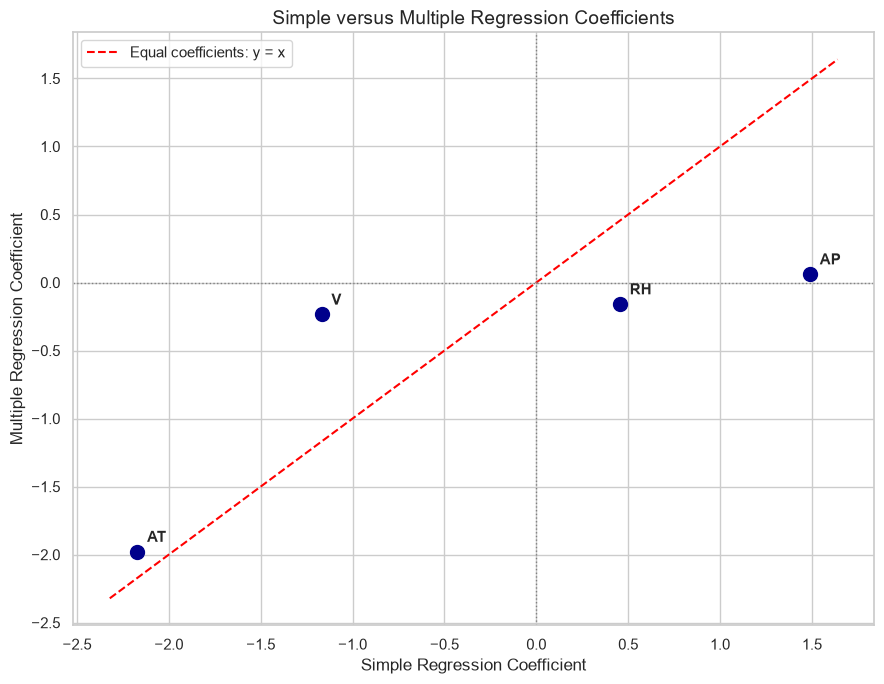

In [21]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 7))

plt.scatter(
    coefficient_comparison["Simple Regression"],
    coefficient_comparison["Multiple Regression"],
    color="darkblue",
    s=100
)

# Label each point with its predictor name
for predictor, row in coefficient_comparison.iterrows():
    plt.annotate(
        predictor,
        (
            row["Simple Regression"],
            row["Multiple Regression"]
        ),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )


all_coefficients = coefficient_comparison.to_numpy().flatten()
minimum = all_coefficients.min()
maximum = all_coefficients.max()
padding = 0.15

line_min = minimum - padding
line_max = maximum + padding

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Equal coefficients: y = x"
)


plt.axhline(0, color="gray", linestyle=":", linewidth=1)
plt.axvline(0, color="gray", linestyle=":", linewidth=1)

plt.xlabel("Simple Regression Coefficient", fontsize=12)
plt.ylabel("Multiple Regression Coefficient", fontsize=12)
plt.title(
    "Simple versus Multiple Regression Coefficients",
    fontsize=14
)

plt.legend()
plt.tight_layout()
plt.show()

All four predictors were statistically significant in both the simple and multiple regression models. However, their coefficient estimates changed after the other predictors were included in the model.

The coefficient for ambient temperature (AT) changed from approximately −2.171 in the simple regression to −1.978 in the multiple regression. Its direction and magnitude remained relatively similar, suggesting that temperature has a strong negative association with electrical energy output even after controlling for the other predictors.

The coefficient for exhaust vacuum (V) decreased substantially in magnitude, from approximately −1.168 to −0.234. This suggests that part of the negative association observed in the simple regression was related to the association between V and the other predictors, particularly AT.

The coefficient for ambient pressure (AP) decreased from approximately 1.490 to 0.062. Although AP remained statistically significant, its conditional association with power output was much smaller after controlling for temperature, vacuum, and humidity.

Relative humidity (RH) showed the most notable directional change. Its simple regression coefficient was positive, approximately 0.456, but its multiple regression coefficient was negative, approximately −0.158. The simple model suggests that higher humidity is associated with higher power output, but after controlling for the other predictors, higher humidity is associated with lower power output.

In [22]:
df[predictors].corr().round(3)

,AT,V,AP,RH
AT,1.000,0.844,-0.508,-0.543
V,0.844,1.000,-0.414,-0.312
AP,-0.508,-0.414,1.000,0.100
RH,-0.543,-0.312,0.100,1.000


The reason for these changes is that the predictors are correlated.
AT and V have a correlation of approximately 0.844, while AT and RH have a correlation of approximately −0.543. Consequently, the simple regression coefficients partly capture associations belonging to other predictors. The multiple regression coefficients estimate each predictor’s effect after statistically controlling for those relationships.

### (f) Nonlinear Association

In [23]:
predictors = ["AT", "V", "AP", "RH"]

polynomial_models = {}
nonlinear_results = []

for predictor in predictors:
    temp_df = df[["PE", predictor]].copy()

    # Centering improves numerical stability.
    # It does not change the fitted cubic curve.
    predictor_mean = temp_df[predictor].mean()
    temp_df["X_centered"] = temp_df[predictor] - predictor_mean

    # Linear model
    linear_model = smf.ols(
        "PE ~ X_centered",
        data=temp_df
    ).fit()

    # Cubic polynomial model
    cubic_model = smf.ols(
        "PE ~ X_centered + I(X_centered**2) + I(X_centered**3)",
        data=temp_df
    ).fit()

    # Compare the linear and cubic models
    comparison = anova_lm(linear_model, cubic_model)

    joint_f_statistic = comparison.loc[1, "F"]
    joint_p_value = comparison.loc[1, "Pr(>F)"]

    polynomial_models[predictor] = {
        "model": cubic_model,
        "mean": predictor_mean
    }

    nonlinear_results.append({
        "Predictor": predictor,
        "Linear R-squared": linear_model.rsquared,
        "Cubic R-squared": cubic_model.rsquared,
        "Quadratic p-value": cubic_model.pvalues[
            "I(X_centered ** 2)"
        ],
        "Cubic p-value": cubic_model.pvalues[
            "I(X_centered ** 3)"
        ],
        "Joint F-statistic": joint_f_statistic,
        "Joint p-value": joint_p_value
    })

nonlinear_results = pd.DataFrame(nonlinear_results)
nonlinear_results.round(6)

,Predictor,Linear R-squared,Cubic R-squared,Quadratic p-value,Cubic p-value,Joint F-statistic,Joint p-value
0,AT,0.898948,0.911883,0.000000,0.000000,701.967278,0.000000
1,V,0.756518,0.775022,0.000000,0.013735,393.314147,0.000000
2,AP,0.268769,0.297543,0.000000,0.000000,195.885627,0.000000
3,RH,0.151939,0.153743,0.101395,0.000014,10.188863,0.000038


In [24]:
for predictor in predictors:
    print(f"\n{'=' * 70}")
    print(f"Cubic polynomial regression for {predictor}")
    print("=" * 70)

    print(polynomial_models[predictor]["model"].summary())


Cubic polynomial regression for AT
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:14:16   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------


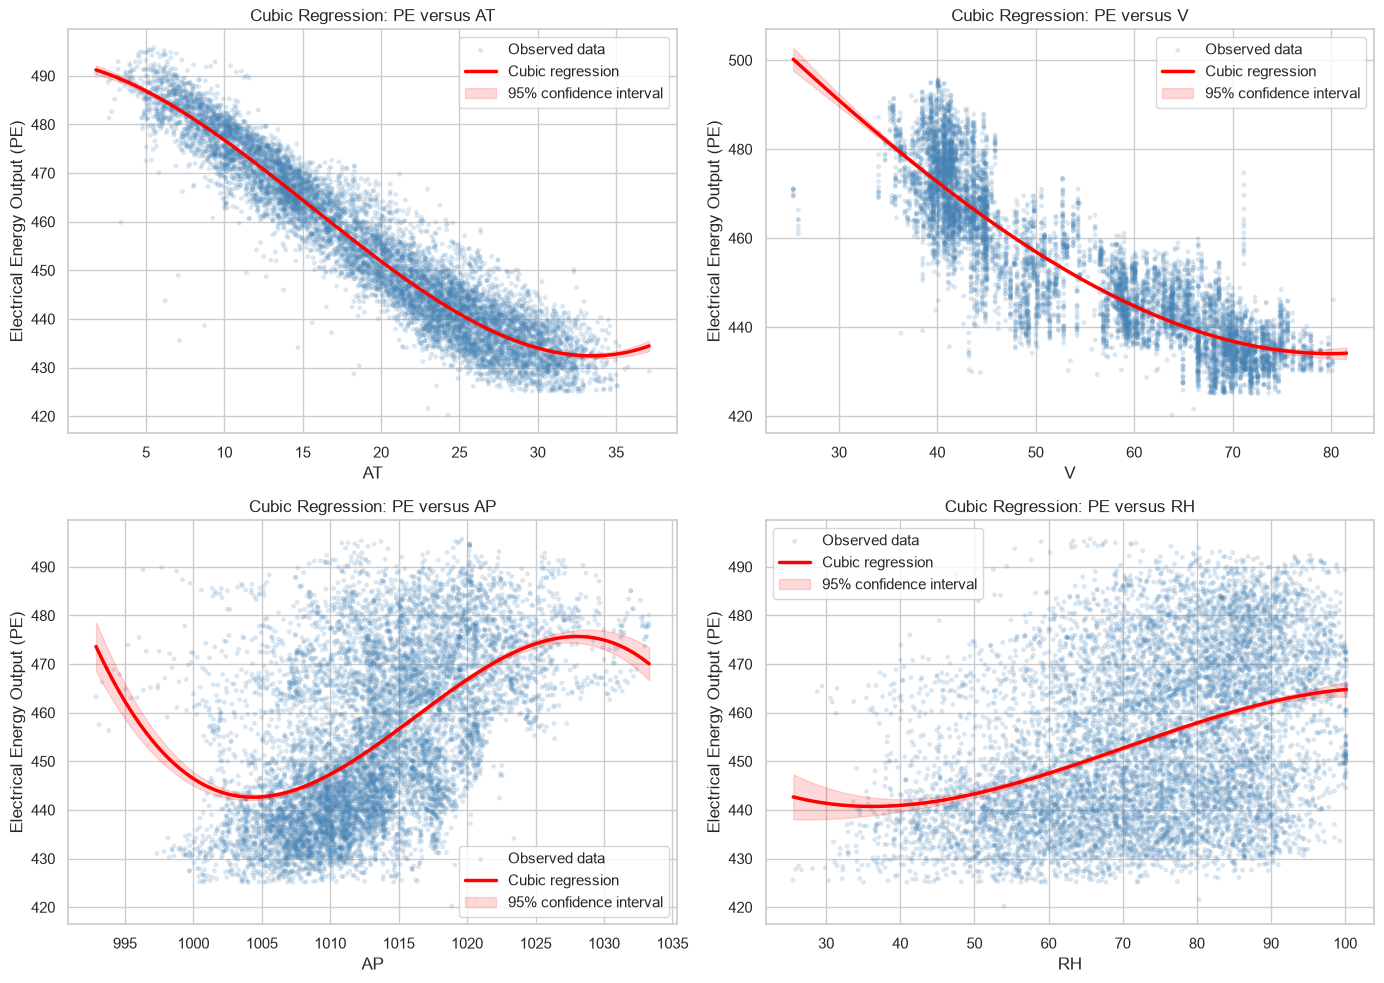

In [25]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    cubic_model = polynomial_models[predictor]["model"]
    predictor_mean = polynomial_models[predictor]["mean"]

    ax.scatter(
        df[predictor],
        df["PE"],
        alpha=0.20,
        s=12,
        color="steelblue",
        edgecolor="none",
        label="Observed data"
    )

    
    x_grid = np.linspace(
        df[predictor].min(),
        df[predictor].max(),
        300
    )

    prediction_data = pd.DataFrame({
        "X_centered": x_grid - predictor_mean
    })

    prediction = cubic_model.get_prediction(
        prediction_data
    ).summary_frame()

    
    ax.plot(
        x_grid,
        prediction["mean"],
        color="red",
        linewidth=2.5,
        label="Cubic regression"
    )

    
    ax.fill_between(
        x_grid,
        prediction["mean_ci_lower"],
        prediction["mean_ci_upper"],
        color="red",
        alpha=0.15,
        label="95% confidence interval"
    )

    ax.set_title(f"Cubic Regression: PE versus {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("Electrical Energy Output (PE)")
    ax.legend()

plt.tight_layout()
plt.show()

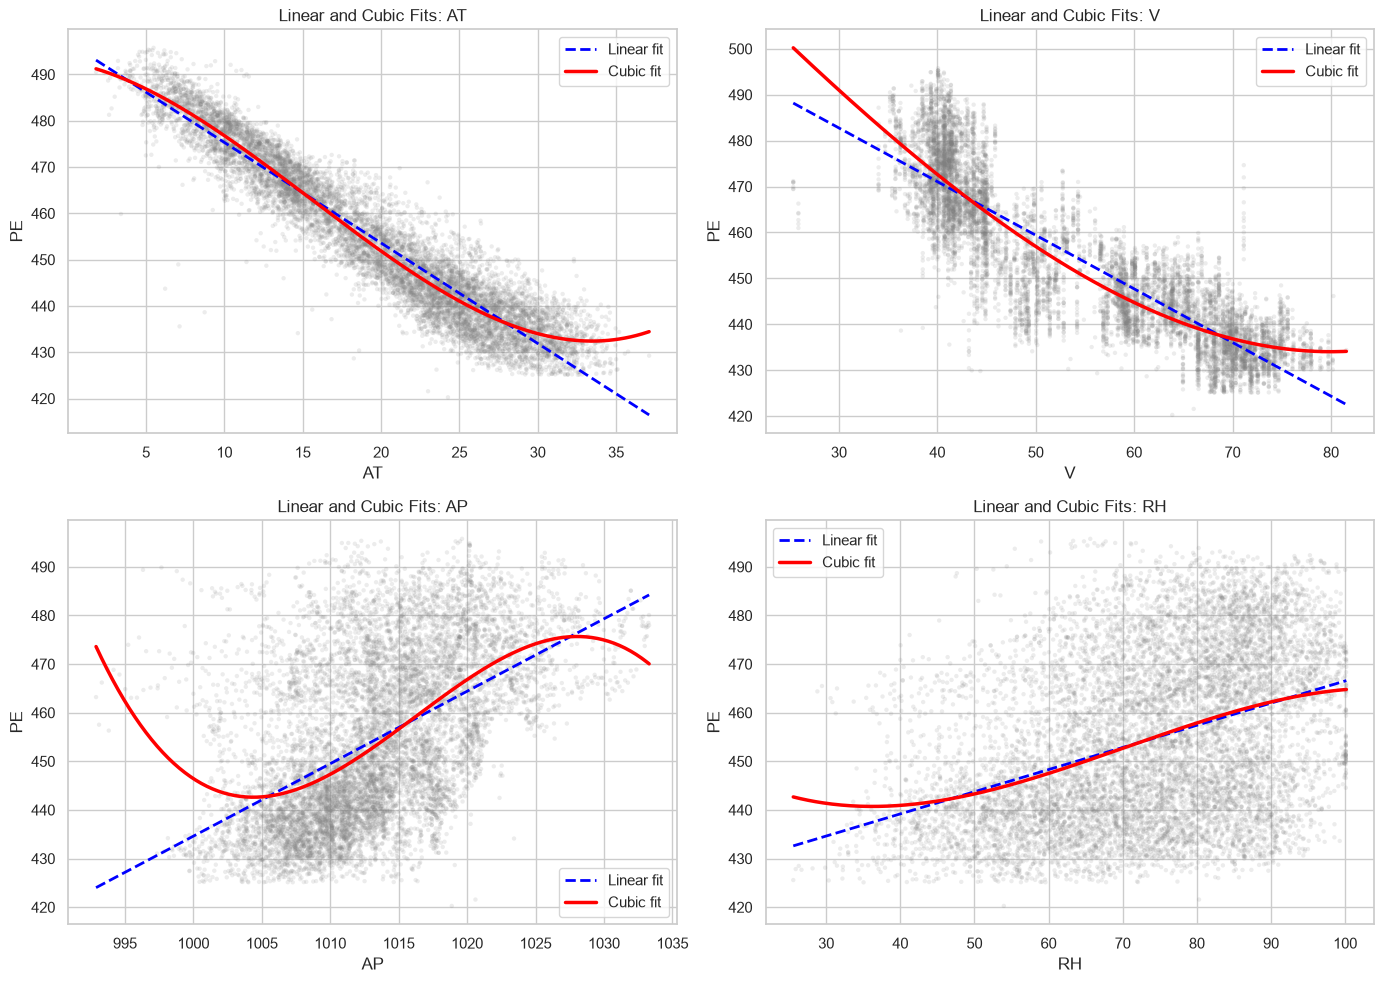

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, predictor in zip(axes, predictors):
    temp_df = df[["PE", predictor]].copy()
    predictor_mean = temp_df[predictor].mean()
    temp_df["X_centered"] = temp_df[predictor] - predictor_mean

    linear_model = smf.ols(
        "PE ~ X_centered",
        data=temp_df
    ).fit()

    cubic_model = polynomial_models[predictor]["model"]

    x_grid = np.linspace(
        df[predictor].min(),
        df[predictor].max(),
        300
    )

    prediction_data = pd.DataFrame({
        "X_centered": x_grid - predictor_mean
    })

    linear_predictions = linear_model.predict(prediction_data)
    cubic_predictions = cubic_model.predict(prediction_data)

    ax.scatter(
        df[predictor],
        df["PE"],
        alpha=0.15,
        s=10,
        color="gray",
        edgecolor="none"
    )

    ax.plot(
        x_grid,
        linear_predictions,
        color="blue",
        linewidth=2,
        linestyle="--",
        label="Linear fit"
    )

    ax.plot(
        x_grid,
        cubic_predictions,
        color="red",
        linewidth=2.5,
        label="Cubic fit"
    )

    ax.set_title(f"Linear and Cubic Fits: {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")
    ax.legend()

plt.tight_layout()
plt.show()

The nested-model F-tests provide statistically significant evidence of nonlinear association between electrical energy output and each of the four predictors. For AT, V, AP, and RH, the joint null hypothesis \(H_0:\beta_2=\beta_3=0\) is rejected because each joint p-value is below 0.05.

The strongest evidence of nonlinearity occurs for ambient temperature (AT) and exhaust vacuum (V). Adding the quadratic and cubic terms increases the \(R^2\) for AT from approximately 0.899 to 0.912 and increases the \(R^2\) for V from approximately 0.757 to 0.775. Their fitted curves show visible deviations from straight lines.

Ambient pressure (AP) also has statistically significant nonlinear terms, but its \(R^2\) increases only from approximately 0.269 to 0.275. Relative humidity (RH) has statistically significant nonlinear terms, but its \(R^2\) increases only from approximately 0.152 to 0.154. Therefore, the nonlinear improvements for AP and RH are statistically significant but small in practical terms.

Overall, there is evidence of nonlinear association for all four predictors, but the nonlinear patterns are most meaningful for AT and V.

### (g) Interactions of Predictors

In [27]:
interaction_model = smf.ols(
    formula="PE ~ (AT + V + AP + RH) ** 2",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:14:19   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [28]:
interaction_terms = [
    term
    for term in interaction_model.params.index
    if ":" in term
]

interaction_results = pd.DataFrame({
    "Coefficient": interaction_model.params[interaction_terms],
    "Standard Error": interaction_model.bse[interaction_terms],
    "t-statistic": interaction_model.tvalues[interaction_terms],
    "p-value": interaction_model.pvalues[interaction_terms]
})

interaction_results["Significant at 0.05"] = (
    interaction_results["p-value"] < 0.05
)

interaction_results.round(6)

,Coefficient,Standard Error,t-statistic,p-value,Significant at 0.05
AT:V,0.020971,0.000899,23.337763,0.000000,True
AT:AP,0.001759,0.002339,0.752031,0.452051,False
AT:RH,-0.005230,0.000812,-6.444357,0.000000,True
V:AP,0.006812,0.001327,5.135000,0.000000,True
V:RH,0.000839,0.000489,1.716004,0.086194,False
AP:RH,-0.001612,0.000758,-2.125079,0.033606,True


In [29]:
additive_model = smf.ols(
    formula="PE ~ AT + V + AP + RH",
    data=df
).fit()

interaction_test = anova_lm(
    additive_model,
    interaction_model
)

interaction_test

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,9563.0,198702.459591,0.0,NaN,NaN,NaN
1,9557.0,177496.627095,6.0,21205.832496,190.298584,8.064363e-230


In [30]:
model_comparison = pd.DataFrame({
    "Model": [
        "Additive model",
        "Pairwise interaction model"
    ],
    "R-squared": [
        additive_model.rsquared,
        interaction_model.rsquared
    ],
    "Adjusted R-squared": [
        additive_model.rsquared_adj,
        interaction_model.rsquared_adj
    ],
    "RMSE": [
        additive_model.mse_resid ** 0.5,
        interaction_model.mse_resid ** 0.5
    ]
})

model_comparison.round(4)

,Model,R-squared,Adjusted R-squared,RMSE
0,Additive model,0.9287,0.9287,4.5583
1,Pairwise interaction model,0.9363,0.9362,4.3096


There is evidence that some predictors interact in their association with electrical energy output. At the 0.05 significance level, the AT:V, AT:RH, V:AP, and AP:RH interactions are statistically significant. The AT:AP and V:RH interactions are not statistically significant because their p-values are approximately 0.452 and 0.086, respectively.

The joint F-test comparing the additive model with the full interaction model has a p-value below 0.001. Therefore, we reject the null hypothesis that all six interaction coefficients equal zero. The interaction model increases \(R^2\) from approximately 0.9287 to 0.9363 and reduces RMSE from approximately 4.5583 to 4.3096.

These results indicate that the association between a predictor and electrical energy output can depend on the value of another predictor. For example, the significant AT:V interaction means that the relationship between ambient temperature and power output changes according to the exhaust-vacuum level.

### (h) Improvement

In [31]:
predictors = ["AT", "V", "AP", "RH"]

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 6697
Testing observations: 2871


In [32]:
# Calculate means using only the training data
training_means = train_df[predictors].mean()

def create_features(data, means):
    features = pd.DataFrame(index=data.index)

    # Centered main effects
    for predictor in predictors:
        features[predictor] = (
            data[predictor] - means[predictor]
        )

    # Quadratic terms
    for predictor in predictors:
        features[f"{predictor}_sq"] = (
            features[predictor] ** 2
        )

    # All pairwise interactions
    for first, second in combinations(predictors, 2):
        features[f"{first}_{second}"] = (
            features[first] * features[second]
        )

    return features

X_train_full = create_features(
    train_df,
    training_means
)

X_test_full = create_features(
    test_df,
    training_means
)

y_train = train_df["PE"]
y_test = test_df["PE"]

print(X_train_full.columns.tolist())

['AT', 'V', 'AP', 'RH', 'AT_sq', 'V_sq', 'AP_sq', 'RH_sq', 'AT_V', 'AT_AP', 'AT_RH', 'V_AP', 'V_RH', 'AP_RH']


In [33]:
X_train_baseline = sm.add_constant(
    X_train_full[predictors],
    has_constant="add"
)

X_test_baseline = sm.add_constant(
    X_test_full[predictors],
    has_constant="add"
)

baseline_model = sm.OLS(
    y_train,
    X_train_baseline
).fit()

baseline_train_predictions = baseline_model.predict(
    X_train_baseline
)

baseline_test_predictions = baseline_model.predict(
    X_test_baseline
)

baseline_train_mse = mean_squared_error(
    y_train,
    baseline_train_predictions
)

baseline_test_mse = mean_squared_error(
    y_test,
    baseline_test_predictions
)

print(baseline_model.summary())
print("Baseline train MSE:", baseline_train_mse)
print("Baseline test MSE:", baseline_test_mse)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 2.194e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:14:19   Log-Likelihood:                -19630.
No. Observations:                6697   AIC:                         3.927e+04
Df Residuals:                    6692   BIC:                         3.930e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.4085      0.055   8193.942      0.0

In [34]:
all_features = X_train_full.columns.tolist()

parents = {}

# Quadratic terms require their corresponding main effects
for predictor in predictors:
    parents[f"{predictor}_sq"] = {predictor}

# Interaction terms require both main effects
for first, second in combinations(predictors, 2):
    parents[f"{first}_{second}"] = {first, second}

In [35]:
def fit_model(feature_names):
    X = sm.add_constant(
        X_train_full[feature_names],
        has_constant="add"
    )

    return sm.OLS(y_train, X).fit()


def main_effect_is_required(main_effect, selected_features):
    for higher_order_term, required_parents in parents.items():
        if (
            higher_order_term in selected_features
            and main_effect in required_parents
        ):
            return True

    return False


selected_features = all_features.copy()
removal_history = []

while True:
    current_model = fit_model(selected_features)

    removable_candidates = []

    for feature in selected_features:
        p_value = current_model.pvalues[feature]

        # A main effect cannot be removed when a remaining
        # square or interaction depends on it.
        if feature in predictors:
            if main_effect_is_required(
                feature,
                selected_features
            ):
                continue

        if p_value > 0.05:
            removable_candidates.append(
                (feature, p_value)
            )

    # Stop when every removable variable is significant
    if not removable_candidates:
        break

    # Remove the eligible variable with the largest p-value
    feature_to_remove, largest_p_value = max(
        removable_candidates,
        key=lambda item: item[1]
    )

    selected_features.remove(feature_to_remove)

    removal_history.append({
        "Removed variable": feature_to_remove,
        "p-value when removed": largest_p_value
    })

selected_model = fit_model(selected_features)

In [36]:
removal_history_df = pd.DataFrame(removal_history)
removal_history_df

,Removed variable,p-value when removed
0,V_RH,0.867382
1,V_sq,0.607733
2,V_AP,0.357826


In [37]:
print("Final selected features:")

for feature in selected_features:
    print(feature)

Final selected features:
AT
V
AP
RH
AT_sq
AP_sq
RH_sq
AT_V
AT_AP
AT_RH
AP_RH


In [38]:
print(selected_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:14:19   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        453.2275      0.099   4582.006      0.0

In [39]:
selected_results = pd.DataFrame({
    "Coefficient": selected_model.params,
    "Standard Error": selected_model.bse,
    "t-statistic": selected_model.tvalues,
    "p-value": selected_model.pvalues
})

selected_results.round(6)

,Coefficient,Standard Error,t-statistic,p-value
const,453.227507,0.098915,4582.006192,0.000000
AT,-1.817267,0.019482,-93.280225,0.000000
V,-0.298531,0.008887,-33.593352,0.000000
AP,0.116926,0.011569,10.106816,0.000000
RH,-0.125096,0.005111,-24.473779,0.000000
AT_sq,0.019534,0.002408,8.112485,0.000000
AP_sq,-0.007644,0.001335,-5.725951,0.000000
RH_sq,-0.001940,0.000275,-7.046218,0.000000
AT_V,0.008246,0.001456,5.663172,0.000000
AT_AP,0.006975,0.002197,3.174497,0.001508


In [40]:
X_train_selected = sm.add_constant(
    X_train_full[selected_features],
    has_constant="add"
)

X_test_selected = sm.add_constant(
    X_test_full[selected_features],
    has_constant="add"
)

selected_train_predictions = selected_model.predict(
    X_train_selected
)

selected_test_predictions = selected_model.predict(
    X_test_selected
)

selected_train_mse = mean_squared_error(
    y_train,
    selected_train_predictions
)

selected_test_mse = mean_squared_error(
    y_test,
    selected_test_predictions
)

mse_results = pd.DataFrame({
    "Model": [
        "Baseline additive model",
        "Selected nonlinear/interaction model"
    ],
    "Train MSE": [
        baseline_train_mse,
        selected_train_mse
    ],
    "Test MSE": [
        baseline_test_mse,
        selected_test_mse
    ]
})

mse_results.round(4)

,Model,Train MSE,Test MSE
0,Baseline additive model,20.5808,21.2399
1,Selected nonlinear/interaction model,17.8908,18.6600


In [41]:
test_mse_reduction = (
    (baseline_test_mse - selected_test_mse)
    / baseline_test_mse
) * 100

print(
    f"Test MSE reduction: {test_mse_reduction:.2f}%"
)

Test MSE reduction: 12.15%


The data were randomly divided into a 70% training set and a 30% test set using random_state=42. The baseline multiple-regression model included the four predictors AT, V, AP, and RH. It produced a training MSE of approximately 20.5808 and a test MSE of approximately 21.2399.

The expanded model initially included all four main effects, four quadratic terms, and six pairwise interactions. Backward elimination using a 0.05 significance level removed V:RH, \(V^2\), and V:AP. Model hierarchy was preserved throughout the procedure, meaning that the relevant main effects were retained whenever a quadratic or interaction term involving them remained.

The selected model had a training MSE of approximately 17.8908 and a test MSE of approximately 18.6600. Therefore, including the selected quadratic and interaction terms reduced the test MSE by approximately 12.15%. This indicates that nonlinearities and interactions improve prediction beyond the purely additive linear model. The training and test MSEs are also reasonably close, so there is no strong indication of severe overfitting.

### (i) KNN

In [42]:
predictors = ["AT", "V", "AP", "RH"]

X = df[predictors]
y = df["PE"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 6697
Testing observations: 2871


In [43]:
scaler = MinMaxScaler()

X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

In [44]:
k_values = range(1, 101)

raw_train_mse = []
raw_test_mse = []

normalized_train_mse = []
normalized_test_mse = []

for k in k_values:
    # KNN using raw features
    raw_model = KNeighborsRegressor(
        n_neighbors=k
    )

    raw_model.fit(X_train, y_train)

    raw_train_predictions = raw_model.predict(X_train)
    raw_test_predictions = raw_model.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(
            y_train,
            raw_train_predictions
        )
    )

    raw_test_mse.append(
        mean_squared_error(
            y_test,
            raw_test_predictions
        )
    )

    # KNN using normalized features
    normalized_model = KNeighborsRegressor(
        n_neighbors=k
    )

    normalized_model.fit(
        X_train_normalized,
        y_train
    )

    normalized_train_predictions = (
        normalized_model.predict(X_train_normalized)
    )

    normalized_test_predictions = (
        normalized_model.predict(X_test_normalized)
    )

    normalized_train_mse.append(
        mean_squared_error(
            y_train,
            normalized_train_predictions
        )
    )

    normalized_test_mse.append(
        mean_squared_error(
            y_test,
            normalized_test_predictions
        )
    )

In [45]:
best_raw_index = np.argmin(raw_test_mse)
best_normalized_index = np.argmin(normalized_test_mse)

best_raw_k = list(k_values)[best_raw_index]
best_normalized_k = list(k_values)[best_normalized_index]

print("Raw features")
print("Best k:", best_raw_k)
print(
    "Training MSE:",
    raw_train_mse[best_raw_index]
)
print(
    "Testing MSE:",
    raw_test_mse[best_raw_index]
)

print("\nNormalized features")
print("Best k:", best_normalized_k)
print(
    "Training MSE:",
    normalized_train_mse[best_normalized_index]
)
print(
    "Testing MSE:",
    normalized_test_mse[best_normalized_index]
)

Raw features
Best k: 5
Training MSE: 10.600768887561596
Testing MSE: 15.726819842563568

Normalized features
Best k: 4
Training MSE: 8.454347681797822
Testing MSE: 14.291333431295715


In [46]:
knn_results = pd.DataFrame({
    "k": list(k_values),
    "1/k": [1 / k for k in k_values],
    "Raw Train MSE": raw_train_mse,
    "Raw Test MSE": raw_test_mse,
    "Normalized Train MSE": normalized_train_mse,
    "Normalized Test MSE": normalized_test_mse
})

knn_results.head()

,k,1/k,Raw Train MSE,Raw Test MSE,Normalized Train MSE,Normalized Test MSE
0,1,1.000000,0.000000,20.332543,0.000000,18.298757
1,2,0.500000,5.500468,17.344087,5.204069,15.700308
2,3,0.333333,8.126551,16.338840,7.168283,14.605432
3,4,0.250000,9.444740,15.810755,8.454348,14.291333
4,5,0.200000,10.600769,15.726820,9.602599,14.446174


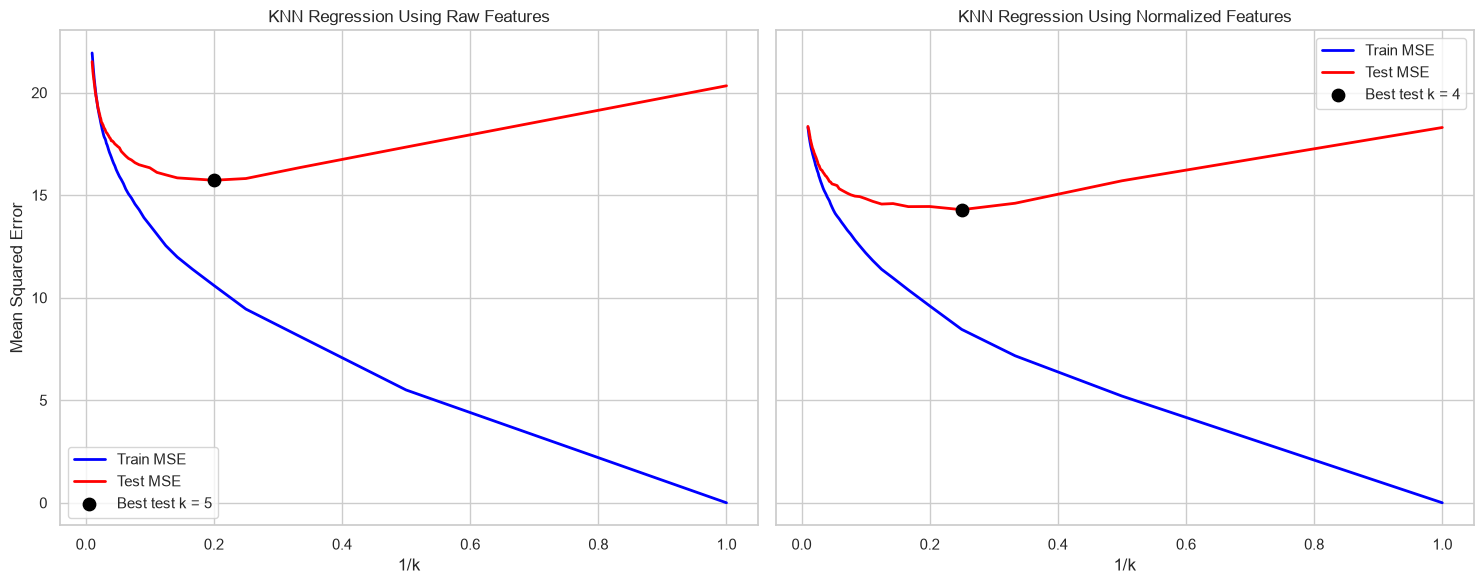

In [47]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
    sharey=True
)

# Sort so that 1/k increases from left to right
plot_results = knn_results.sort_values("1/k")

# Raw features
axes[0].plot(
    plot_results["1/k"],
    plot_results["Raw Train MSE"],
    label="Train MSE",
    color="blue",
    linewidth=2
)

axes[0].plot(
    plot_results["1/k"],
    plot_results["Raw Test MSE"],
    label="Test MSE",
    color="red",
    linewidth=2
)

axes[0].scatter(
    1 / best_raw_k,
    raw_test_mse[best_raw_index],
    color="black",
    s=80,
    zorder=5,
    label=f"Best test k = {best_raw_k}"
)

axes[0].set_title("KNN Regression Using Raw Features")
axes[0].set_xlabel("1/k")
axes[0].set_ylabel("Mean Squared Error")
axes[0].legend()

# Normalized features
axes[1].plot(
    plot_results["1/k"],
    plot_results["Normalized Train MSE"],
    label="Train MSE",
    color="blue",
    linewidth=2
)

axes[1].plot(
    plot_results["1/k"],
    plot_results["Normalized Test MSE"],
    label="Test MSE",
    color="red",
    linewidth=2
)

axes[1].scatter(
    1 / best_normalized_k,
    normalized_test_mse[best_normalized_index],
    color="black",
    s=80,
    zorder=5,
    label=f"Best test k = {best_normalized_k}"
)

axes[1].set_title(
    "KNN Regression Using Normalized Features"
)
axes[1].set_xlabel("1/k")
axes[1].legend()

plt.tight_layout()
plt.show()

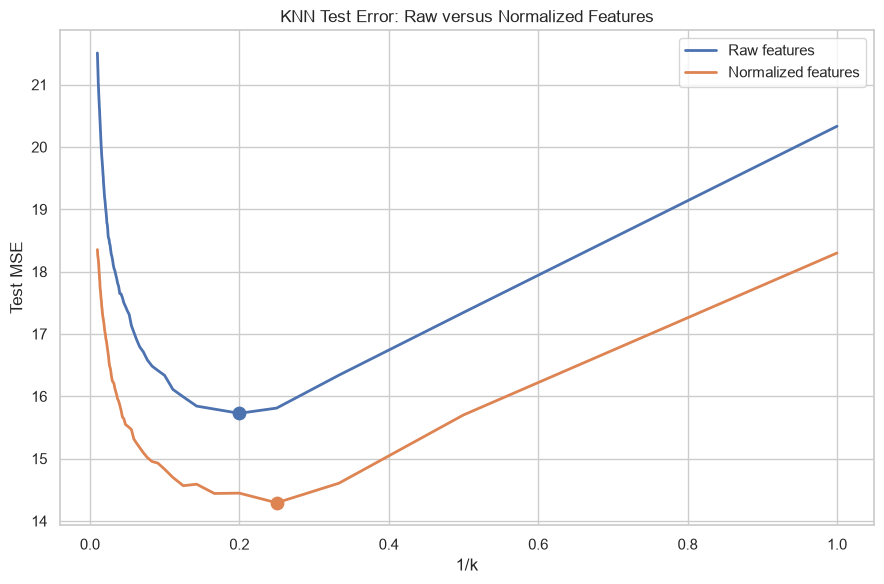

In [48]:
plt.figure(figsize=(9, 6))

plt.plot(
    plot_results["1/k"],
    plot_results["Raw Test MSE"],
    label="Raw features",
    linewidth=2
)

plt.plot(
    plot_results["1/k"],
    plot_results["Normalized Test MSE"],
    label="Normalized features",
    linewidth=2
)

plt.scatter(
    1 / best_raw_k,
    raw_test_mse[best_raw_index],
    s=80,
    zorder=5
)

plt.scatter(
    1 / best_normalized_k,
    normalized_test_mse[best_normalized_index],
    s=80,
    zorder=5
)

plt.xlabel("1/k")
plt.ylabel("Test MSE")
plt.title("KNN Test Error: Raw versus Normalized Features")
plt.legend()
plt.tight_layout()
plt.show()

K-nearest neighbor regression was evaluated for every \(k\) from 1 through 100 using both raw and normalized predictors. The same 70/30 training-test split was used for both approaches.

Using the raw predictors, the minimum test MSE occurred at \(k=5\). This model had a training MSE of approximately 10.6008 and a test MSE of approximately 15.7268.

After normalizing the predictors to the interval \([0,1]\), the minimum test MSE occurred at \(k=4\). The normalized model had a training MSE of approximately 8.4543 and a test MSE of approximately 14.2913. Therefore, the normalized KNN model provided the better test-set performance.

Normalization improves KNN because its predictions depend directly on distances between observations. Without normalization, predictors with larger numerical ranges can have disproportionately large effects on the distance calculation.

At \(k=1\), the training MSE is zero because each training observation is its own nearest neighbor. However, its test error is higher, indicating overfitting. As \(k\) increases, the model becomes smoother: training error generally increases, while test error initially decreases and then increases after the optimal value of \(k\).

### (j ) Compare KNN and Linear

In [49]:
model_comparison = pd.DataFrame({
    "Model": [
        "Selected nonlinear/interaction regression",
        "KNN using raw features (k=5)",
        "KNN using normalized features (k=4)"
    ],
    "Train MSE": [
        selected_train_mse,
        raw_train_mse[best_raw_index],
        normalized_train_mse[best_normalized_index]
    ],
    "Test MSE": [
        selected_test_mse,
        raw_test_mse[best_raw_index],
        normalized_test_mse[best_normalized_index]
    ]
})

model_comparison["Train-Test Gap"] = (
    model_comparison["Test MSE"]
    - model_comparison["Train MSE"]
)

model_comparison.round(4)

,Model,Train MSE,Test MSE,Train-Test Gap
0,Selected nonlinear/interaction regression,17.8908,18.6600,0.7692
1,KNN using raw features (k=5),10.6008,15.7268,5.1261
2,KNN using normalized features (k=4),8.4543,14.2913,5.8370


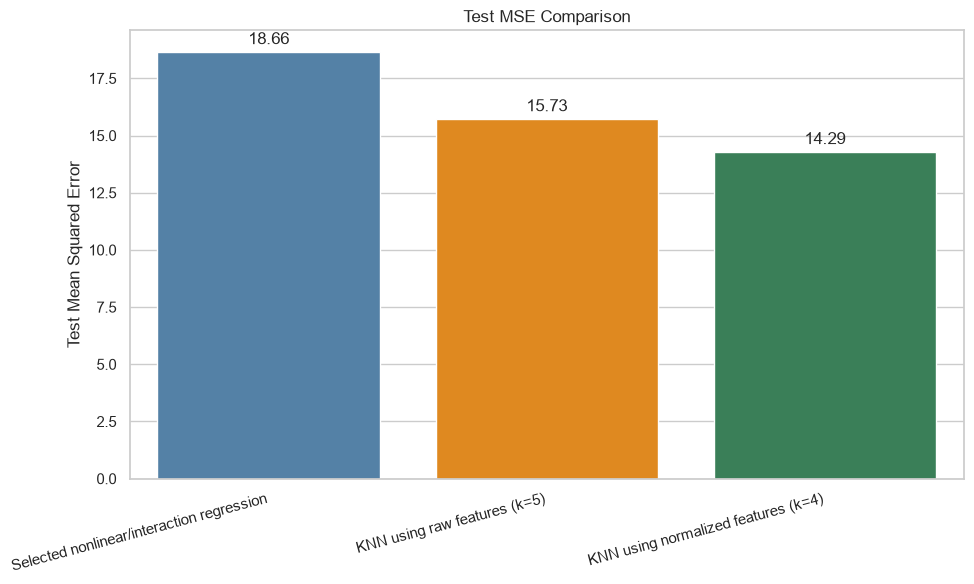

In [50]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=model_comparison,
    x="Model",
    y="Test MSE",
    hue="Model",
    palette=["steelblue", "darkorange", "seagreen"],
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title("Test MSE Comparison")
plt.xlabel("")
plt.ylabel("Test Mean Squared Error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [51]:
normalized_improvement = (
    (
        selected_test_mse
        - normalized_test_mse[best_normalized_index]
    )
    / selected_test_mse
) * 100

raw_improvement = (
    (
        selected_test_mse
        - raw_test_mse[best_raw_index]
    )
    / selected_test_mse
) * 100

normalization_improvement = (
    (
        raw_test_mse[best_raw_index]
        - normalized_test_mse[best_normalized_index]
    )
    / raw_test_mse[best_raw_index]
) * 100

print(
    "Normalized KNN improvement over regression:",
    f"{normalized_improvement:.2f}%"
)

print(
    "Raw KNN improvement over regression:",
    f"{raw_improvement:.2f}%"
)

print(
    "Normalized KNN improvement over raw KNN:",
    f"{normalization_improvement:.2f}%"
)

Normalized KNN improvement over regression: 23.41%
Raw KNN improvement over regression: 15.72%
Normalized KNN improvement over raw KNN: 9.13%


Among the regression models, the selected model containing significant quadratic and interaction terms had the smallest test MSE of approximately 18.6600. However, both KNN models achieved lower test errors. Raw KNN with \(k=5\) had a test MSE of approximately 15.7268, while normalized KNN with \(k=4\) achieved the lowest test MSE of approximately 14.2913.

The normalized KNN model reduced test MSE by approximately 23.41% relative to the selected regression model. It also reduced test MSE by approximately 9.13% compared with KNN using raw features. This confirms that normalization is important for KNN because its predictions are based on distances between observations.

KNN likely performs better because it can capture local and irregular relationships without requiring those relationships to follow a predetermined linear or polynomial equation. The regression model captures selected quadratic and interaction effects, but its functional form is still globally constrained.

The regression model has a much smaller difference between training and test MSE, indicating more stable performance and less variance. It is also considerably easier to interpret because its coefficients describe the estimated effects of the predictors. KNN has a larger train-test gap and does not provide directly interpretable coefficients, but it provides better predictive accuracy on this test set.

Therefore, normalized KNN with \(k=4\) is the preferred model when prediction accuracy is the primary objective. The nonlinear/interaction regression model may still be preferable when interpretation and explanation of predictor effects are more important.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would generally perform better.

With many observations and only a few predictors, the model has enough data to estimate a complex relationship reliably. The risk of overfitting is relatively low, so a flexible method can capture patterns that an inflexible method might miss.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would generally perform worse.

When $n$ is small and $p$ is large, flexible models easily fit the noise in the data rather than the true underlying relationship, leading to severe overfitting and high variance. An inflexible method imposes structural constraints that restrict model complexity, keeping variance manageable.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would generally perform better.

Inflexible methods (such as linear regression) make rigid structural assumptions about the function $f(X)$. If the true relationship is non-linear, an inflexible method will suffer from high bias. A flexible method has the degrees of freedom required to fit complex non-linear patterns, yielding lower bias and better overall fit.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would generally perform worse.

High error variance means the data contain substantial random noise. A flexible method may mistakenly fit this noise as though it were a real pattern, causing high variance and overfitting. An inflexible method is less likely to follow the noise and will generally perform better on unseen data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

The Euclidean distance between each observation $X=(X_1,X_2,X_3)$ and the test point $X_0 = (0,0,0)$ is calculated using $d(X,X_0)=\sqrt{(X_1-0)^2+(X_2-0)^2+(X_3-0)^2}$:

Observation 1: \(0,3,0\), Red:\
 $\sqrt{(0-0)^2 + (3-0)^2 + (0-0)^2} = \sqrt{9} = 3$  

Observation 2: \(2,0,0\), Red:\
 $\sqrt{(2-0)^2 + (0-0)^2 + (0-0)^2} = \sqrt{4} = 2$  

Observation 3: \(0,1,3\), Red:\
 $\sqrt{(0-0)^2 + (1-0)^2 + (3-0)^2} = \sqrt{1 + 9} = \sqrt{10} \approx 3.16$  

Observation 4: \(0,1,2\), Green:\
 $\sqrt{(0-0)^2 + (1-0)^2 + (2-0)^2} = \sqrt{1 + 4} = \sqrt{5} \approx 2.24$  

Observation 5: \(-1,0,1\), Green:\
 $\sqrt{(-1-0)^2 + (0-0)^2 + (1-0)^2} = \sqrt{1 + 1} = \sqrt{2} \approx 1.41$  

Observation 6: \(1,1,1\), Red:\
 $\sqrt{(1-0)^2 + (1-0)^2 + (1-0)^2} = \sqrt{1 + 1 + 1} = \sqrt{3} \approx 1.73$

### (b) What is our prediction with K = 1? Why?

For K=1, we use only the single closest observation.

The single nearest neighbor (smallest distance) to the test point is Observation 5 with $d = \sqrt{2} \approx 1.41$.

Since its class label is Green, the 1-nearest neighbor classification prediction is Green.

Prediction: Green

### (c) What is our prediction with K = 3? Why?

For K=3, we use only the 3 closest observations.

The three nearest neighbors to the test point are:  
Observation 5 ($d \approx 1.41$, Y = Green)  
Observation 6 ($d \approx 1.73$, Y = Red)  
Observation 2 ($d = 2.00$, Y = Red)

Among these 3 neighbors, the probability of   
Y = Red is $2/3 \approx 66.7\%$ and   
Y = Green is $1/3 \approx 33.3\%$.

By majority vote, the prediction is Red.

Prediction: Red


### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would generally expect the best value of K to be small.

A small K produces a flexible decision boundary because the prediction depends only on observations very close to the test point. This allows KNN to follow complex, highly nonlinear patterns.

A large K averages over many observations and produces a smoother, less flexible decision boundary. It may fail to capture a highly nonlinear relationship.

Therefore, 
A small value of K is generally preferred.

The exact best value should still be selected using validation or cross-validation because making K too small can lead to overfitting.

## References and Citations

The following resources were consulted while completing this assignment:

1. **James, G., Witten, D., Hastie, T., Tibshirani, R., and Taylor, J.**  
   *An Introduction to Statistical Learning: With Applications in Python.*  
   Used as a reference for simple and multiple linear regression, polynomial regression, interaction effects, model assessment, the bias–variance trade-off, and K-nearest neighbors.  
   https://www.statlearning.com/

2. **UCI Machine Learning Repository — Combined Cycle Power Plant Dataset.**  
   Used for the dataset description, predictor definitions, response-variable information, and original data source.  
   https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant

3. **Statsmodels — Ordinary Least Squares Regression.**  
   Used as a reference for fitting and interpreting OLS regression models, coefficient estimates, standard errors, t-statistics, p-values, \(R^2\), and adjusted \(R^2\).  
   https://www.statsmodels.org/stable/regression.html

4. **Statsmodels — Interactions and ANOVA.**  
   Used as a reference for fitting interaction models and comparing nested regression models with F-tests.  
   https://www.statsmodels.org/stable/examples/notebooks/generated/interactions_anova.html

5. **Scikit-learn — `train_test_split`.**  
   Used to create reproducible training and testing subsets of the dataset.  
   https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

6. **Scikit-learn — `MinMaxScaler`.**  
   Used to normalize the predictor variables before applying KNN regression. The scaler was fitted only on the training data to prevent data leakage.  
   https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html

7. **Scikit-learn — `KNeighborsRegressor`.**  
   Used as a reference for implementing K-nearest neighbor regression and evaluating different values of \(k\).  
   https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html

8. **Scikit-learn — `mean_squared_error`.**  
   Used to calculate and compare the training and testing mean squared errors of the regression models.  
   https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html